In [1]:
%matplotlib inline

import sys

sys.path.append('..')

import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import product
from datetime import datetime
import os
import glob
import matplotlib.pyplot as plt
from open_ocean.utils import convert_climatology_to_ocean_areas
import open_ocean.gridder as gridder
import open_ocean.interpolation as io

In [2]:
data_dir = Path(os.getenv("OODIR"))
coder = xr.coders.CFDatetimeCoder(time_unit="s")

In [3]:
climatology = xr.open_dataset(data_dir / "SST_CCI_climatology" / "SST_1x1_daily.nc")
areas = convert_climatology_to_ocean_areas(climatology)
sampling_unc = xr.open_dataset(data_dir / "IQUAM" / "OutputData" / "sampling_uncertainty.nc")

In [4]:
data_file = data_dir / "IQUAM" / "OutputData" / "timeseries_with_uncertainty.csv"
data = pd.read_csv(data_file, header=[0, 1], index_col=0)
time = np.arange(len(data)) / 12. + 1981 + 8 / 12.

ship = data['ship']['Global']
ship_unc = data['ship_unc']['Global']

drifter = data['drifter']['Global']
drifter_unc = data['drifter_unc']['Global']

argo = data['argo']['Global']
argo_unc = data['argo_unc']['Global']

interp = data['interp']['Global']
interp_unc = data['interp_unc']['Global']

In [5]:
icoads_data_file = data_dir / "ICOADS" / "OutputData" / "timeseries_with_uncertainty.csv"
icoads_data = pd.read_csv(icoads_data_file, header=[0, 1], index_col=0)
icoads_time = np.arange(len(icoads_data)) / 12. + 1850.

icship = icoads_data['ship']['Global']
icship_unc = icoads_data['ship_unc']['Global']

icdrifter = icoads_data['drifter']['Global']
icdrifter_unc = icoads_data['drifter_unc']['Global']

icinterp = icoads_data['interp']['Global']
icinterp_unc = icoads_data['interp_unc']['Global']

icinterp2 = icoads_data['interp2']['Global']
icinterp2_unc = icoads_data['interp2_unc']['Global']

(-0.5, 0.86)

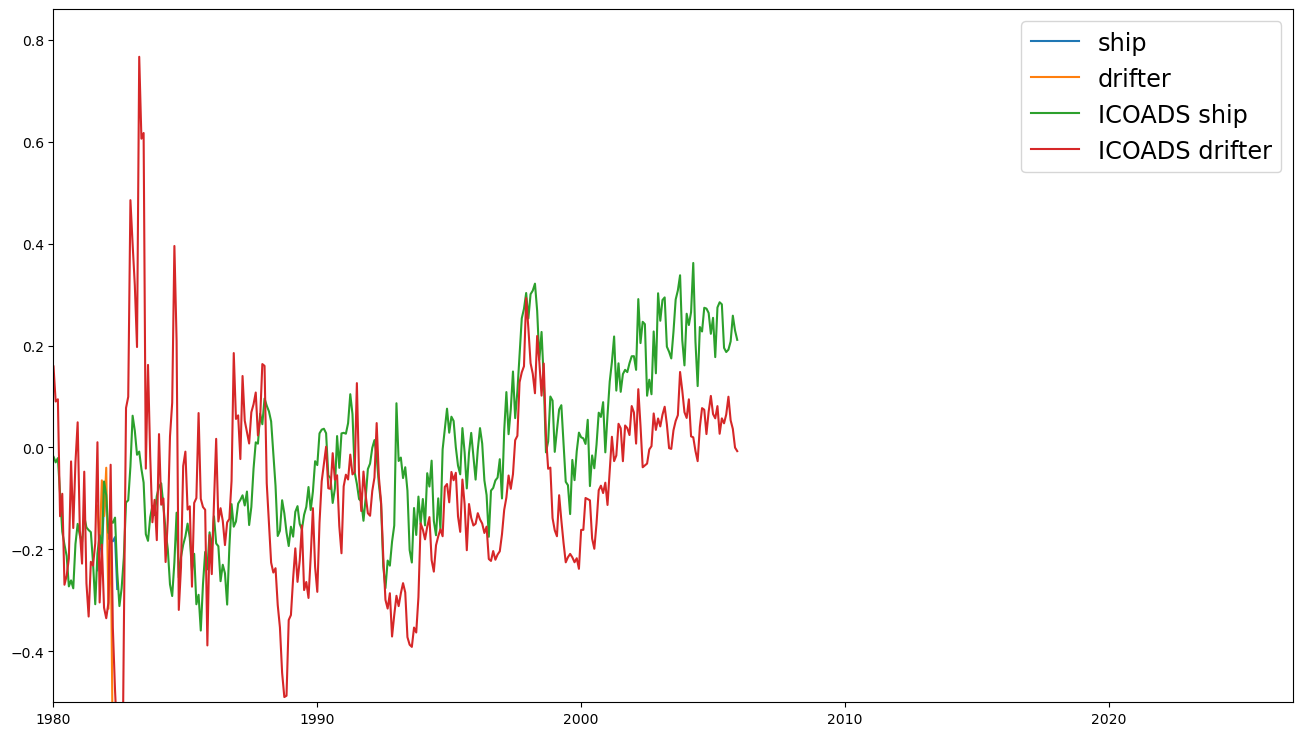

In [15]:
plt.figure()
plt.gcf().set_size_inches(16, 9)

plt.plot(time, ship, label='ship')
plt.plot(time, drifter, label='drifter')

plt.plot(icoads_time, icship, label='ICOADS ship')
plt.plot(icoads_time, icdrifter, label='ICOADS drifter')

plt.legend(fontsize='xx-large')
plt.xlim(1980, 2027)
plt.ylim(-0.5, 0.86)

(-0.5, 0.86)

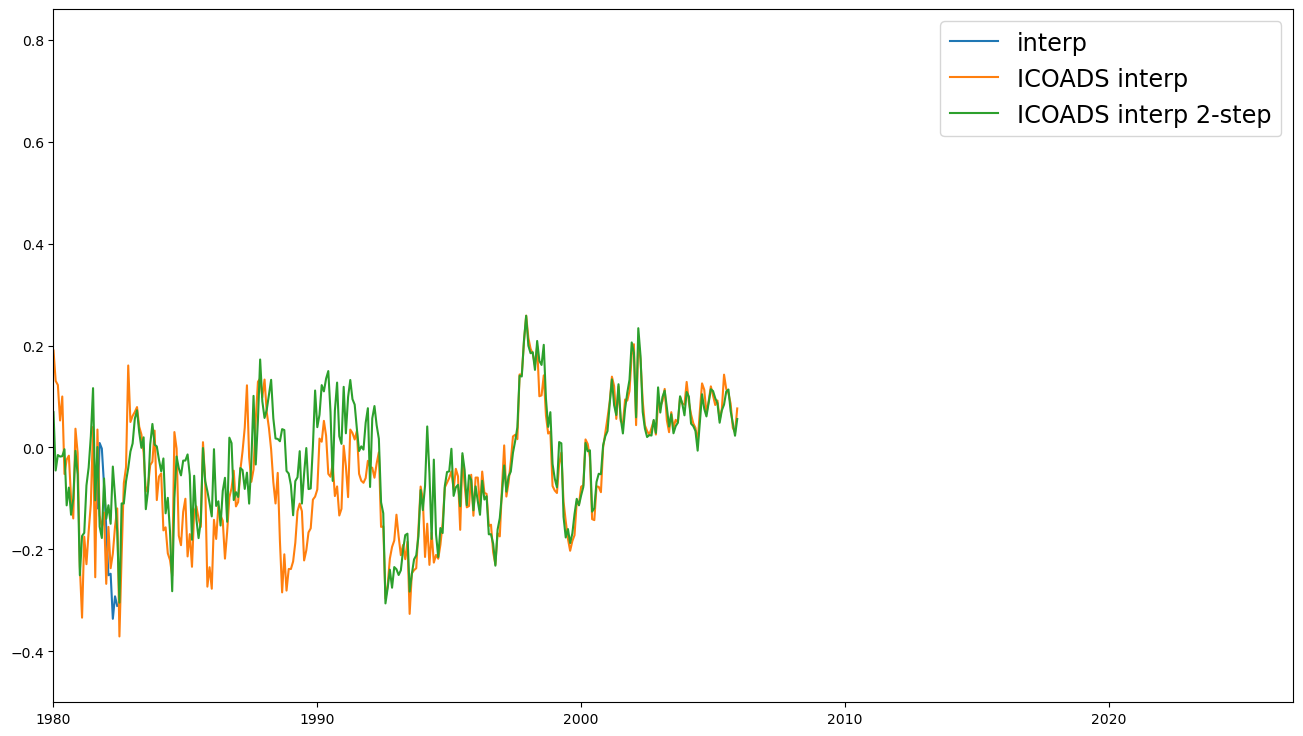

In [16]:
plt.figure()
plt.gcf().set_size_inches(16, 9)

plt.plot(time, interp, label='interp')

plt.plot(icoads_time, icinterp, label='ICOADS interp')
plt.plot(icoads_time, icinterp2, label='ICOADS interp 2-step')

plt.legend(fontsize='xx-large')
plt.xlim(1980, 2027)
plt.ylim(-0.5, 0.86)

In [17]:
climatology = xr.open_dataset(data_dir / "SST_CCI_climatology" / "SST_1x1_daily.nc")
cos_lat_weights = np.cos(np.deg2rad(climatology.latitude))

# Use the SST values in the climatology as an ocean mask. Set area to 1 for gridcells with SSTs, 0 otherwise
climatology = climatology.sst[0].values
ocean = np.where(np.isnan(climatology), 0.0, 1.0)

# Areas are proportional to the cosine of latitude multiplied by the ocean area in the grid cell
areas = np.zeros((36, 72))
for xx, yy in product(range(72), range(36)):
    areas[yy, xx] = np.mean(ocean[yy*5:(yy+1)*5, xx*5:(xx+1)*5]) * np.cos(np.pi*(yy*5 - 87.5)/180.)

# normalise the areas to one at the equator
areas = areas/np.max(areas)

hadsst4 = xr.open_dataset(data_dir / "ManagedData" / "Data" / "HadSST4" / "HadSST.4.1.1.0_median.nc")

lat_slice = hadsst4.tos.sel(latitude=slice(-90, 90))
lat_lon_slice = lat_slice.sel(longitude=slice(-180, 180))

weights = lat_lon_slice[0]
weights.values = areas

h4_weighted_mean = lat_lon_slice.weighted(weights).mean(("longitude", "latitude"))
h4_time = np.arange(len(h4_weighted_mean))/12. + 1850.

In [8]:
filepath = data_dir/ 'ERSSTv6'
files = filepath.glob('ersst.v6.*.nc')
ersst = xr.open_mfdataset(files)

In [9]:
climatology = xr.open_dataset(data_dir / "SST_CCI_climatology" / "SST_1x1_daily.nc")
climatology = climatology.sst[0].values
ocean = np.where(np.isnan(climatology), 0.0, 1.0)
ocean = np.roll(ocean, 180, axis=1)
ersst_areas = np.zeros((89, 180))
for xx, yy in product(range(180), range(89)):
    ersst_areas[yy, xx] = np.mean(ocean[yy*2+1:(yy+1)*2+1, xx*2:(xx+1)*2]) * np.cos(np.pi*(yy*2 - 88.0)/180.)

In [10]:
lat_slice = ersst.ssta.sel(lat=slice(-90, 90))
lat_lon_slice = lat_slice.sel(lon=slice(0, 360))
weights = lat_lon_slice[0]
weights.values = np.reshape(ersst_areas, (1, 89, 180)) # ERSST has an extra lev dimension for some reason
ersst_weighted_mean = lat_lon_slice.weighted(weights).mean(("lon", "lat")).values
ersst_time = np.arange(len(ersst_weighted_mean))/12. + 1850.


In [11]:
filepath = data_dir / 'SST_CCI' / 'SST_ANOM_100_19800101_20250630_regridded'
files = filepath.glob('*.nc')
sst_cci = xr.open_mfdataset(files)

In [12]:
lat_slice = sst_cci.sst_anomaly.sel(lat=slice(-90, 90))
lat_lon_slice = lat_slice.sel(lon=slice(-180, 180))
weights = np.cos(np.deg2rad(lat_lon_slice.lat))
cci_weighted_mean = lat_lon_slice.weighted(weights).mean(("lon", "lat")).values
cci_time = np.arange(len(cci_weighted_mean))/12. + 1980.

(-0.5, 0.86)

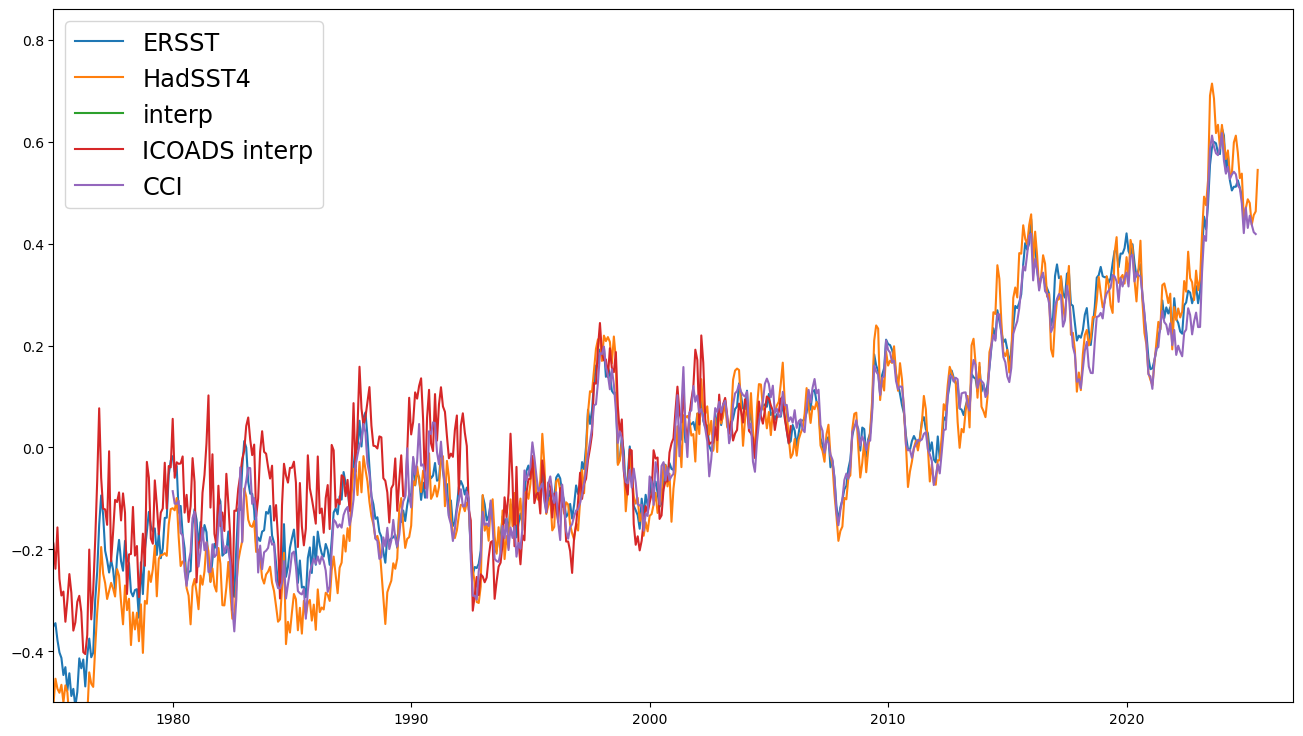

In [28]:
plt.figure()
plt.gcf().set_size_inches(16, 9)
y1=1995
y2=2005
selection = (time >= y1) & (time <=y2)
icselection = (icoads_time >= y1) & (icoads_time <=y2)
hselection = (h4_time >= y1) & (h4_time <=y2)
eselection = (ersst_time >= y1) & (ersst_time <=y2)
cselection = (cci_time >= y1) & (cci_time <=y2)

plt.plot(ersst_time, ersst_weighted_mean - np.mean(ersst_weighted_mean[eselection]), label='ERSST')
plt.plot(h4_time, h4_weighted_mean - np.mean(h4_weighted_mean[hselection]), label='HadSST4')
plt.plot(time, interp - np.mean(interp[selection]), label='interp')
plt.plot(icoads_time, icinterp2 - np.mean(icinterp2[icselection]), label='ICOADS interp')
plt.plot(cci_time, cci_weighted_mean - np.mean(cci_weighted_mean[cselection]), label='CCI')

plt.legend(fontsize='xx-large')
plt.xlim(1975, 2027)
plt.ylim(-0.5, 0.86)

(-1.5, 0.86)

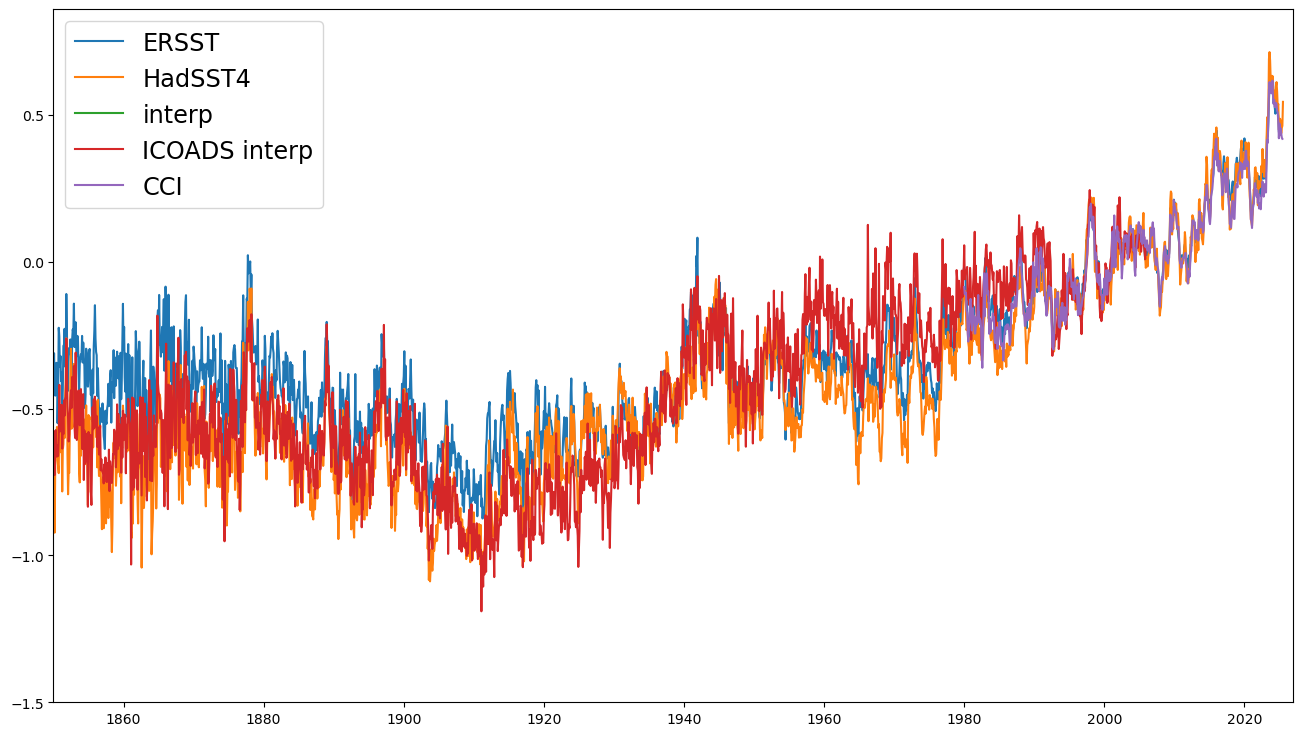

In [26]:
plt.figure()
plt.gcf().set_size_inches(16, 9)
y1=1995
y2=2005
selection = (time >= y1) & (time <=y2)
icselection = (icoads_time >= y1) & (icoads_time <=y2)
hselection = (h4_time >= y1) & (h4_time <=y2)
eselection = (ersst_time >= y1) & (ersst_time <=y2)
cselection = (cci_time >= y1) & (cci_time <=y2)

plt.plot(ersst_time, ersst_weighted_mean - np.mean(ersst_weighted_mean[eselection]), label='ERSST')
plt.plot(h4_time, h4_weighted_mean - np.mean(h4_weighted_mean[hselection]), label='HadSST4')
plt.plot(time, interp - np.mean(interp[selection]), label='interp')
plt.plot(icoads_time, icinterp2 - np.mean(icinterp2[icselection]), label='ICOADS interp')
plt.plot(cci_time, cci_weighted_mean - np.mean(cci_weighted_mean[cselection]), label='CCI')

plt.legend(fontsize='xx-large')
plt.xlim(1850, 2027)
plt.ylim(-1.5, 0.86)

C:\Users\johnk\anaconda3\envs\open_ocean\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\johnk\anaconda3\envs\open_ocean\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(-1.2, 0.63)

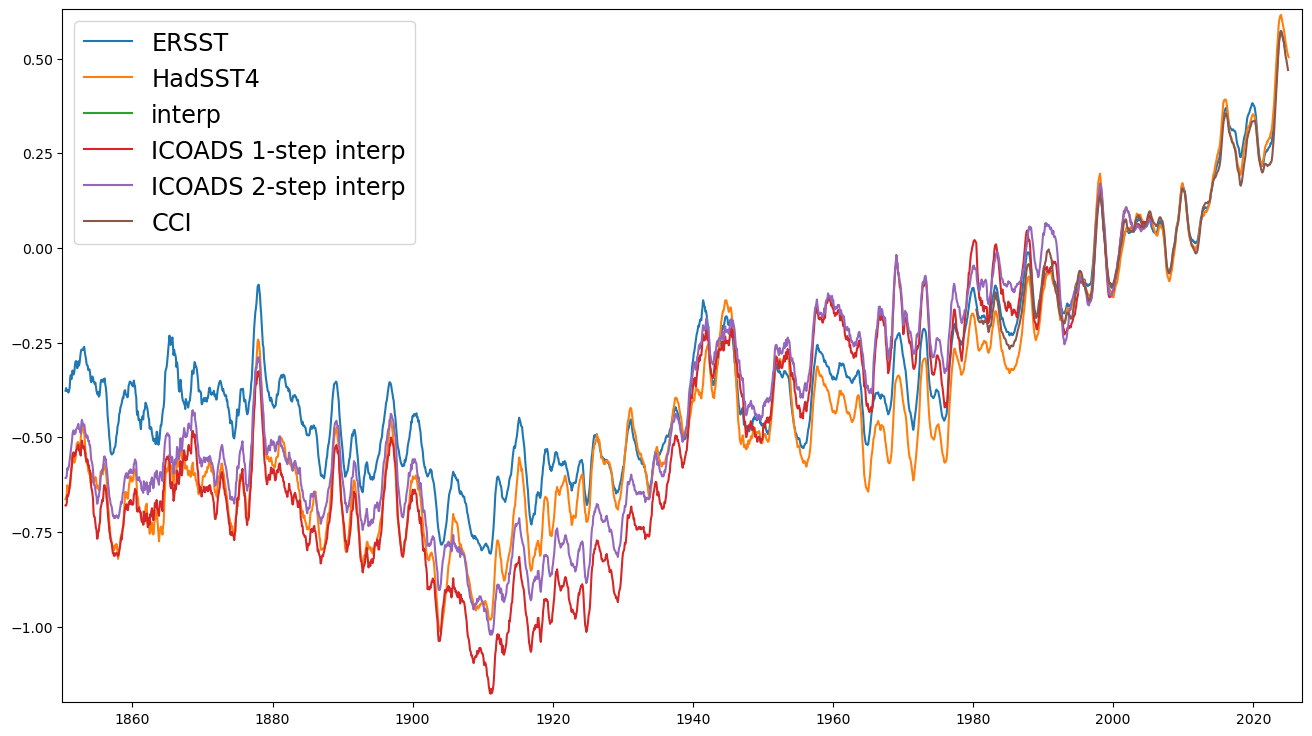

In [27]:
def ma(a, n=12):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

plt.figure()
plt.gcf().set_size_inches(16, 9)

plt.plot(ma(ersst_time), ma(ersst_weighted_mean - np.mean(ersst_weighted_mean[eselection])), label='ERSST')
plt.plot(ma(h4_time), ma(h4_weighted_mean.values - np.mean(h4_weighted_mean.values[hselection])), label='HadSST4')
plt.plot(ma(time), ma(interp.values - np.mean(interp.values[selection])), label='interp')
plt.plot(ma(icoads_time), ma(icinterp.values - np.mean(icinterp.values[icselection])), label='ICOADS 1-step interp')
plt.plot(ma(icoads_time), ma(icinterp2.values - np.mean(icinterp2.values[icselection])), label='ICOADS 2-step interp')
plt.plot(ma(cci_time), ma(cci_weighted_mean - np.mean(cci_weighted_mean[cselection])), label='CCI')

plt.legend(fontsize='xx-large')
plt.xlim(1850, 2027)
plt.ylim(-1.2, 0.63)